## Problema - Organización y búsqueda de productos en una tienda

**Instrucción:** completa esta plantilla con tu diseño y desarrollo. Evita incluir soluciones generadas automáticamente.



In [ ]:
# @title Ingrese datos
nombre_estudiante = "Andrés Felipe Vargas Goméz" # @param {"type":"string"}
carnet = 1000114227 # @param {"type":"integer"}


## 1) Descripción del problema **[1 pts]**


Una plataforma de streaming requiere modelar el comportamiento del crecimiento de nuevos usuarios para estimar el total de registros en el mes **N**. La relacion de recurrencia establece que en el mes 0 no hay nuevos usuarios (T(0)=0), en el mes 1 se registra 1 usuario (T(1)=1) y apartir del mes 2, el numero de usuarios equivale a la suma de los usuarios registrados en los dos meses previos
(**T**(n)=T(n-1)+**T**(n-2)).

para resolver esta relación de recurrencia de manera eficiente y evitar el cálculo redundante de subproblemas se implementa un enfoque de programación dinamica Top-Down

## 2) Requerimientos **[2 pts]**

Lista requerimientos **funcionales** y **no funcionales**.

**REQUERIMIENTOS FUNCIONALES :**

-Calcular la cantidad exacta de nuevos suscriptores en el mes **n** para cualquier **n**>= 0.

-Retornar 0 cuando **n**=0 y cuando **n**=1.

-Implementar un arrelgo de memoización para almacenar y consultar resultados de subproblemas ya resueltos.

-Validar que la entrada **n** sea un entero positivo, para retornar excepciones controladas si no cumple.

**REQUERIMIENTOS NO FUNCIONALES :**

-El algoritmo debe ejecutarse en el tiempo **O(n)**

-La funcion debe de validar las entradas para evitar fallos inesperados, lanzando excepciones si se ingresan valores negativos o datos que sean de un tipo distinto a un entero


-El código debe de ser claro y fácil de leer

-Cada subproblema de calcularse una unica vez y ser almacenado en el diccionario memo



## 3) Historias de usuario **[2 pts]**
Escribe 3–5 historias de usuario con el formato visto en clase:
Incluye criterios de aceptación.


**HISTORIA 1 :** Consulta de nuevos suscriptores

**Como** analista de datos de la plataforma

**Quiero** ingresar el número de mes **n**

**Para** ver la proyección de nuevos suscriptores en dicho período.

**Criterios de aceptación :**

-Si **n**=0 el sistema retorna 0.

-Si **n**= 1, el sistema retorna 1.

-Si **n**=6, el sistema retorna 8.

**HISTORIA 2 :** Consulta de nuevos

**Como** Desarrollador del sistema


**Quiero** Guardar en la memoria los valores de los meses ya calculados


**Para** Evitar cálculos repetidos y procesar valores grandes de **n** de forma rápida.


**Criterios de aceptación :**

-Los resultados de cada mes se almacenan en un arreglo.

-La respuesta para **n**= 100 se genera en menos de un segundo.

**HISTORIA 3 :** Control de entradas no válidas


**Como** Usuario de la plataforma


**Quiero** quiero que la función valide la entrada **n**


**Para** Evitar errores de ejecución cuando introduzca datos incorrectos.


**Criterios de aceptación :**

-Si se ingresa un número negativo (**n** <0 ) retorna un error

-si se ingresa un tipo de dato que no sea entero por ejemplo un caracter especial, texto o un decimal) retornar un error.

## 4) Diagramas de flujo **[5 pts]**
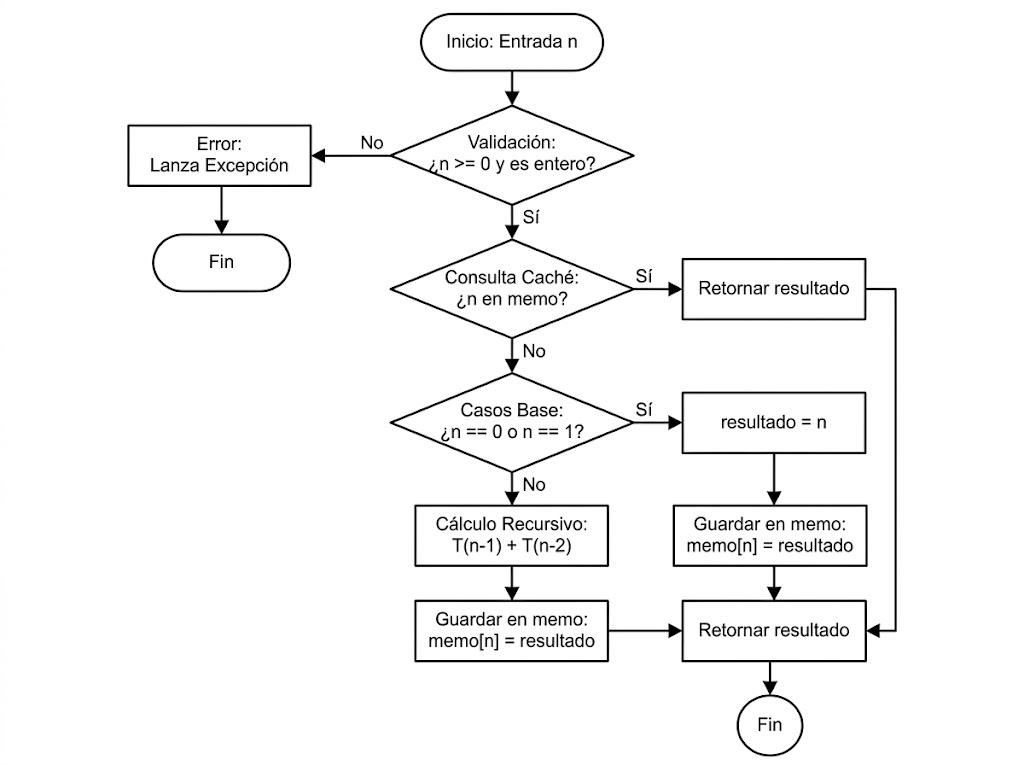


**DESCRIPCIÓN DEL PROCESO**

1.**Inicio :** Se recibe el parámetro **n** y el arreglo opcional

2.**Validación :** Se verifica si **n** es entero y **n**>=0

3.**Consulta de Caché :** Se comprueba si **n** existe en **memo**. Si existe, retorna **memo[n]**

4.**Evaluación Casos Base :**

-Si **n**=0, retorna 0.

-Si¨**n**= 1, retorna 1.

5.**Paso recursivo :** Si



### 5) Análisis de complejidad **[15 pts]**
Incluye:
-1. **Justificación**
La estrategia **Top-Down con Memoización** optimiza el cálculo del crecimiento de suscriptores al transformar un árbol de llamadas recursivas binarias exponencial en una secuencia de evaluaciones lineales.
* **Redundancia eliminada:** Sin memoria, calcular el mes $n$ evaluaría repetidamente los mismos subproblemas **(O(2^n))**. Al usar un diccionario como tabla de memoria, cada mes entre **0** y **n** se calcula exactamente una sola vez.
* **Acceso constante:** El almacenamiento y la búsqueda en el diccionario `memo` operan en tiempo constante promedio **O(1)**.
* **Espacio:** Requiere **O(n)** en el arreglo, dando una complejidad espacial total de **O(n)**.



-2. **Función T[n]**:
* Casos base (n = 0 o n = 1):
T(0)=C1, T(1)=C2
   
* Paso recursivo (**n**>= 2):

   T(**n**)=T(**n**-1)T(**n**-2)+O(1)
   
   Como la llamada de la izquierda T(n-1) se resuelve primero, llena el diccionario con todos los valores desde 0 hasta n-1. Cuando el código evalúa T(n-2), el valor ya está guardado y la consulta cuesta O(1).
   La ecuación se simplifica a:
   T(**n**)=T(**n**-1)+C
   
  
   
   Resultado: T(**n**)=C * **n** + C1---> **O(n)** (Complejidad Lineal).




- **Mejor y peor caso con gráfica :**

* Peor Caso (O(n)): Ocurre la primera vez que calculas un mes n con la memoria vacía. Debe hacer **n** llamadas recursivas para llenar el arreglo.

* Mejor Caso (Omega(1)): Ocurre al pedir los casos base **(0 o 1)** o un mes que ya fue calculado antes, entregando el resultado de inmediato desde el arreglo.

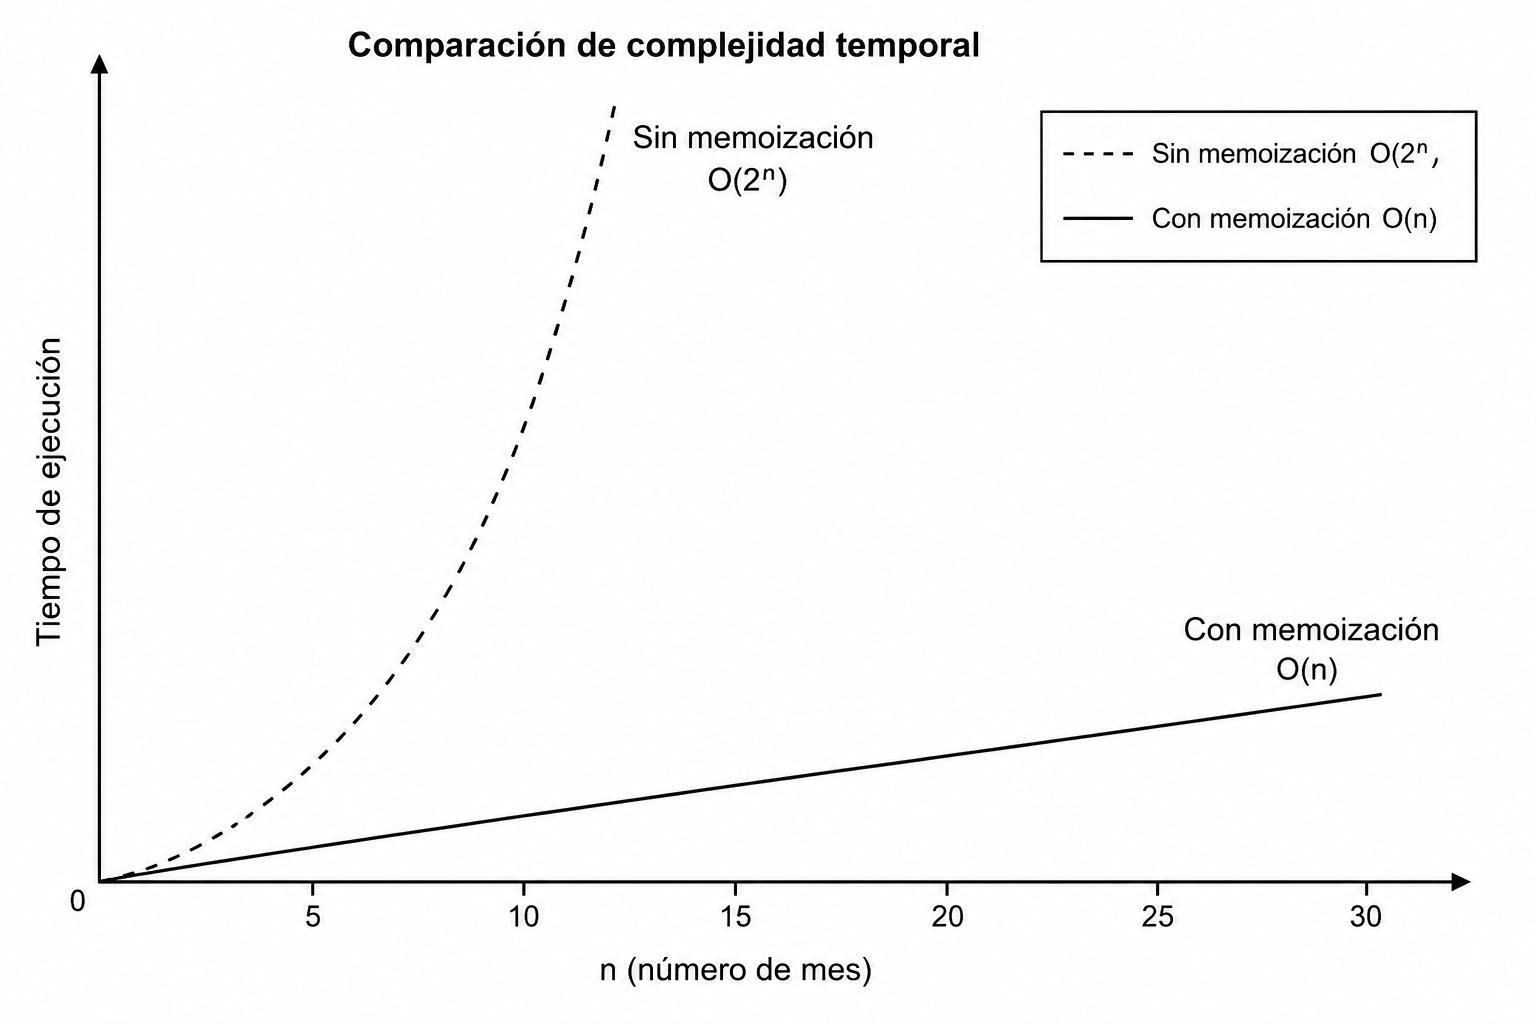

## 6) Código funcional **[15 pts]**
Incluye tu implementación completa.

No pegues código incompleto; debe ser ejecutable.


In [1]:
def suscriptores(n):
    if type(n) != int or n < 0:
        print("Entrada no válida: debe ser un número entero mayor o igual a 0.")
        return None


    def calcular(mes, memo):
        if mes == 0:
            return 0
        if mes == 1:
            return 1
        if mes in memo:
            return memo[mes]

        memo[mes] = calcular(mes - 1, memo) + calcular(mes - 2, memo)
        return memo[mes]

    return calcular(n, {})



entrada = input("Ingrese el mes: ")

if entrada.isdigit():
    mes = int(entrada)
    print("Cantidad de nuevos suscriptores:", suscriptores(mes))
else:
    print("Por favor ingrese un número entero válido.")


Ingrese el mes: 4
Cantidad de nuevos suscriptores: 3


## 7) Tests aplicados **[15 pts]**

In [2]:
# (Opcional) Ejemplo de asserts (ajusta a tu código):
# assert funcion(0) == 0
# assert funcion(1) == 1
# assert funcion(6) == 8
assert suscriptores(0) == 0
assert suscriptores(1) == 1
assert suscriptores(2) == 1
assert suscriptores(3) == 2
assert suscriptores(4) == 3
assert suscriptores(5) == 5
assert suscriptores(6) == 8
